In [2]:
import pandas as pd
deliveries = pd.read_csv('../data/raw/deliveries.csv')
matches = pd.read_csv('../data/raw/matches.csv')

print("Deliveries shape:", deliveries.shape)
print("Matches shape:", matches.shape)

Deliveries shape: (260920, 17)
Matches shape: (1095, 20)


In [2]:
# See first 5 rows of deliveries
print("=== DELIVERIES ===")
print(deliveries.head())

# See first 5 rows of matches
print("\n=== MATCHES ===")
print(matches.head())

# See all column names
print("\n=== DELIVERY COLUMNS ===")
print(deliveries.columns.tolist())

print("\n=== MATCH COLUMNS ===")
print(matches.columns.tolist())

=== DELIVERIES ===
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismiss

In [3]:
print("=== MISSING VALUES IN DELIVERIES ===")
print(deliveries.isnull().sum())

print("\n=== MISSING VALUES IN MATCHES ===")
print(matches.isnull().sum())

print("\n=== TOTAL MATCHES PER SEASON ===")
print(matches['season'].value_counts().sort_index())

=== MISSING VALUES IN DELIVERIES ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

=== MISSING VALUES IN MATCHES ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0


In [5]:
import matplotlib.pyplot as plt

# Filter 2nd innings only
inn2 = deliveries[deliveries['inning'] == 2]

# Merge with matches to get winner
df = inn2.merge(
    matches[['id', 'winner', 'target_runs']],
    left_on='match_id', right_on='id'
)

# Label: did batting team win?
df['batting_team_won'] = (df['batting_team'] == df['winner']).astype(int)

print("Total balls in 2nd innings:", len(df))
print("Matches won by chasing team:", df.groupby('match_id')['batting_team_won'].first().sum())
print("Total matches:", df['match_id'].nunique())

Matplotlib is building the font cache; this may take a moment.


Total balls in 2nd innings: 125741
Matches won by chasing team: 590
Total matches: 1092


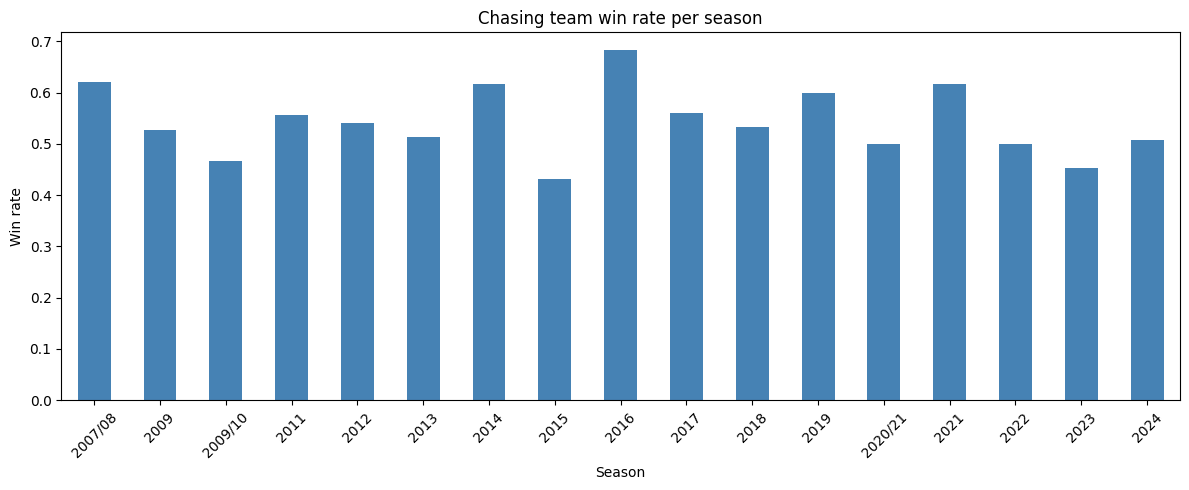

Chart saved!


In [7]:
import matplotlib.pyplot as plt

# Get one row per match with season and result
match_results = df.groupby('match_id').agg(
    batting_team_won=('batting_team_won', 'first')
).reset_index()

match_results = match_results.merge(
    matches[['id','season']], left_on='match_id', right_on='id'
)

# Win rate per season
season_win_rate = match_results.groupby('season')['batting_team_won'].mean()

plt.figure(figsize=(12,5))
season_win_rate.plot(kind='bar', color='steelblue')
plt.title('Chasing team win rate per season')
plt.xlabel('Season')
plt.ylabel('Win rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/win_rate_by_season.png', dpi=150)
plt.show()

print("Chart saved!")

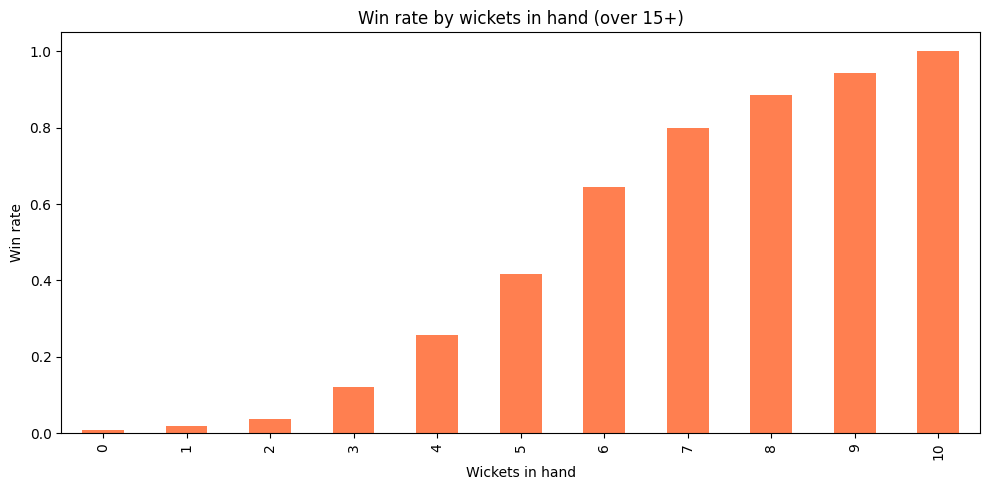

In [8]:
# Compute wickets fallen per ball
df_sorted = df.sort_values(['match_id','over','ball'])
df_sorted['wickets_fallen'] = df_sorted.groupby('match_id')['is_wicket'].cumsum()
df_sorted['wickets_in_hand'] = 10 - df_sorted['wickets_fallen']

# Filter only over 15 onwards (death overs)
death = df_sorted[df_sorted['over'] >= 15]

# Win rate by wickets in hand
win_by_wickets = death.groupby('wickets_in_hand')['batting_team_won'].mean()

plt.figure(figsize=(10,5))
win_by_wickets.plot(kind='bar', color='coral')
plt.title('Win rate by wickets in hand (over 15+)')
plt.xlabel('Wickets in hand')
plt.ylabel('Win rate')
plt.tight_layout()
plt.show()